In [1]:
from fastai.vision.all import *

## Approch 1

- Use CNN to classify fall or not fall
- The classical way

In [2]:
import pandas as pd
import numpy as np

from scipy.signal import ShortTimeFFT
from scipy.signal.windows import hamming

sampling_frequency = 200 # Hz

def create_false_spectrogams(df: pd.DataFrame, SECONDS: int = 2, nperseg=None, train_seconds=None, val_seconds=None, test_seconds=None, mode='train'):
    all_spectrograms = []
    all_labels = []
    segments = []

    treshold = 3

    peak_time = df[df["sensor_1"] == df["sensor_1"].max()]["time_sec"].max()

    start_fall = peak_time - treshold
    end_fall = peak_time + treshold
    
    segments.append((df["time_sec"].min(), start_fall))
    segments.append((end_fall, df["time_sec"].max()))

    samples_per_interval = int(sampling_frequency * SECONDS)

    for start_sec, end_sec in segments:
        num_segments = int((end_sec - start_sec) // SECONDS)

        

        for i in range(num_segments):
            segment_start_time = start_sec + i * SECONDS
            segment_end_time = segment_start_time + SECONDS

            spec_8ch = get_8_channel_spectrogram(
                df[(df["time_sec"] >= segment_start_time) & (df["time_sec"] <= segment_end_time)], nperseg)

            all_spectrograms.append(spec_8ch)
            all_labels.append("Not Fall")

            print(f"Generated {i+1} spectrograms - label: Not Fall")

    return all_spectrograms, all_labels


def create_true_spectrograms(df : pd.DataFrame, SECONDS : int=2, nperseg=None, train_seconds=None, val_seconds=None, test_seconds=None, mode='train'):
    """
    Generates and returns spectrograms for specified time segments.

    Parameters:
    dataDict (dict): Dict containing fault category data.
    fault_category (str): Category to process.
    SECONDS (int): Length of each spectrogram segment in seconds.
    nperseg (int): FFT window size.
    train_seconds (list of tuples): List of (start, end) in seconds for training.
    val_seconds (list of tuples): List of (start, end) in seconds for validation.
    mode (str): 'train' or 'val' - determines which segments to use.

    Returns:
    spectrograms, labels
    """
    all_spectrograms = []
    all_labels = []
    segments = []

    treshold = 3

    peak_time = df[df["sensor_1"] == df["sensor_1"].max()]["time_sec"].max()

    start_time = peak_time - treshold
    end_time = peak_time + treshold
    
    segments.append((start_time, end_time))

    for start_sec, end_sec in segments:
        num_segments = int((end_sec - start_sec) // SECONDS)

        for i in range(num_segments):
            spec_8ch = get_8_channel_spectrogram(
                df[(df["time_sec"] >= start_time) & (df["time_sec"] <= end_time)], nperseg)

            all_spectrograms.append(spec_8ch)
            all_labels.append("Fall")

            print(f"Generated {i+1} spectrograms - label: Fall")

    return all_spectrograms, all_labels

def get_8_channel_spectrogram(data, sampling_frequency = 200, nperseg = 256):

    all_spectrograms = []

    # Slice to first 5 seconds if desired
    
    for column in data:
        if column.startswith("sensor_1") or column.startswith("sensor_2") or column.startswith("sensor_3") or column.startswith("sensor_4"): # This can be used to filter out specific columns
            
            col = data[column]
            w = hamming(nperseg) # Hamming window
            Sft = ShortTimeFFT(w, hop=int(nperseg*0.25), fs=sampling_frequency, scale_to='psd')
            Sxx = Sft.spectrogram(col.values)  # calculate absolute square of STFT
            all_spectrograms.append(Sxx)

    return np.stack(all_spectrograms, axis=0)

In [27]:
from pathlib import Path
import os

def get_data(dir: Path):
    directory = os.listdir(str(dir))
    
    data = []
    fault_labels = []

    for file in directory:
        if (("Session" in file and "_rel_time" in file)):
            df = pd.DataFrame(pd.read_csv(str(dir/file)))
            t_spec, t_labels = create_true_spectrograms(df, SECONDS=3, nperseg=256)
            f_spec, f_labels = create_false_spectrogams(df, SECONDS=3, nperseg=256)
            
            f_spec = f_spec[:len(t_spec)]
            f_labels = f_labels[:len(t_labels)]

            data += t_spec
            data += f_spec

            fault_labels += t_labels
            fault_labels += f_labels
    
    return data, fault_labels

In [4]:
def load_data():
    test_spectograms = []
    test_labels = []

    validation_path = Path('./.data/train')



    controlled = Path(validation_path/'controlledFall')
    hard = Path(validation_path/'hardFall')
    slipTrip = Path(validation_path/'Slip/Trip')

    
    controlled_falls, controlled_labels = get_data(controlled)
    hard_falls, hard_labels = get_data(hard)
    slip_trip_fall, slipTrip_labels = get_data(slipTrip)
    
    test_spectograms += controlled_falls
    test_labels += controlled_labels

    test_spectograms += hard_falls
    test_labels += hard_labels

    test_spectograms += slip_trip_fall
    test_labels += slipTrip_labels

    return test_spectograms, test_labels

In [28]:
spec, labels = load_data()

Generated 1 spectrograms - label: Fall
Generated 2 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 3 spectrograms - label: Not Fall
Generated 4 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 3 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 2 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 3 spectrograms - label: Not Fall
Generated 4 spectrograms - label: Not Fall
Generated 5 spectrograms - label: Not Fall
Generated 6 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: Not Fall
Generated 3 spectrograms - label: Not Fall
Generated 1 spectrograms - label: Fall
Generated 2 spectrograms - label: Fall
Generated 1 spectrograms - label: Not Fall
Generated 2 spectrograms - label: N

In [29]:
len(spec)

586

In [30]:
len(labels)

586

In [53]:
import random

def split():
    valid_spec = []
    valid_labels = []

    size : int = 50
    
    for i in range(0, size):
        ran_num = random.randint(0, len(labels))

        del spec [ran_num]
        del labels [ran_num]

        valid_spec.append(spec[ran_num])
        valid_labels.append(labels[ran_num])
    
    return valid_spec, valid_labels

In [54]:
valid_spec, valid_labels = split()

In [55]:
len(valid_labels)

50

In [56]:
len(labels)

536

In [57]:
print(f'Initial shape of a spectrogram: ', spec[0].shape)

ch, freq_bins, time_bins = spec[0].shape

ratio = 1800/6400
cutoff_idx = int(freq_bins * ratio) # idx to cut the spectrogram
final_shape = (ch, cutoff_idx, time_bins)
print(f'Final shape: {final_shape}')

Initial shape of a spectrogram:  (4, 129, 22)
Final shape: (4, 36, 22)


In [58]:
# constants you can tweak once
FLOOR_DB   = -5.0          # dynamic‑range floor, in dB
TARGET_HW  = (112,112)     # (H, W)
TARGET_CH = 6
EPS = 1e-12
RESIZE_HW  = None

In [59]:
def get_x(i):
    # Normalization - turn spectrogram into dB scale
        arr_db = 10 * np.log10(spec[i])
        arr_db = np.clip(arr_db, FLOOR_DB, 0)

        # Scale to [0, 1]
        arr_01 = (arr_db - FLOOR_DB) / (-FLOOR_DB)

        # If spectrogram is multi-channel, convert to grayscale first
        if len(arr_01.shape) == 3:
                arr_01 = np.mean(arr_01, axis=-1)  # average across channels
        
        arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
        
        # Apply colormap to convert grayscale to color
        # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
        colormap = plt.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
        arr_colored = colormap(arr_01)  # This returns RGBA (H, W, 4)
        
        # Convert RGBA to RGB (drop alpha channel)
        arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
        
        # Convert to PyTorch tensor with correct channel ordering
        t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
        
        # Resize image
        t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
        
        return TensorImage(t_resized.squeeze(0))  # (3, H, W)

def get_y(i):
    return labels[i]

In [60]:
import fastai


block = DataBlock(
    blocks=(TransformBlock(), CategoryBlock(sort=False)),
    get_items=lambda x: x,
    get_x=get_x,
    get_y=get_y,
)

In [61]:
items = list(range(len(spec)))   # or `range(N)`
dls = block.dataloaders(items, bs=12)

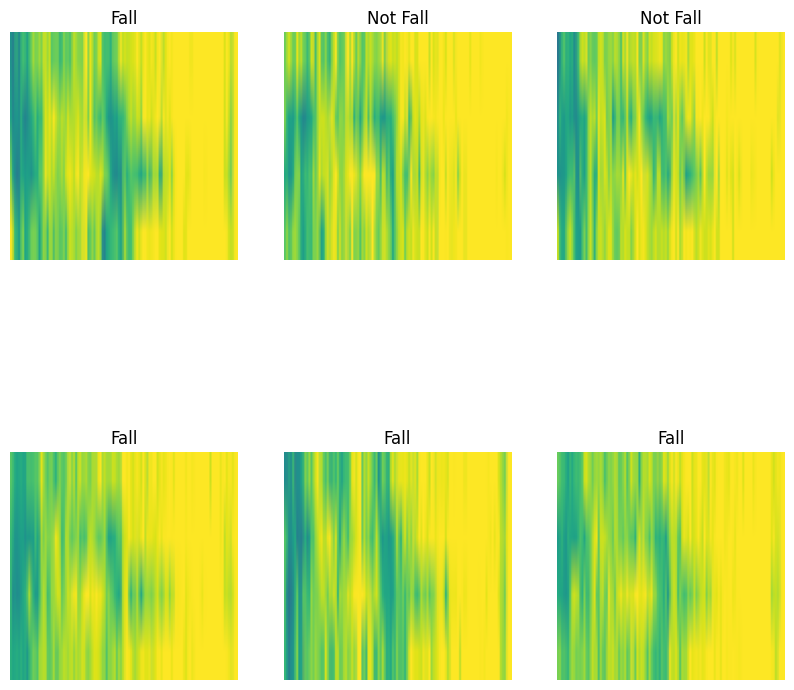

In [76]:
dls.show_batch(max_n=6, figsize=(10,10))

In [63]:
learner = vision_learner(dls, resnet18, metrics=accuracy, loss_func=CrossEntropyLossFlat())

In [64]:
learner.model[-1] = nn.Sequential(learner.model[-1], nn.ReLU())

In [65]:
learner.summary()

Sequential (Input shape: 12 x 3 x 112 x 112)
Layer (type)         Output Shape         Param #    Trainable 
                     12 x 64 x 56 x 56   
Conv2d                                    9408       False     
BatchNorm2d                               128        True      
ReLU                                                           
____________________________________________________________________________
                     12 x 64 x 28 x 28   
MaxPool2d                                                      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                                                           
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
Conv2d                                    36864      False     
BatchNorm2d                               128        True      
ReLU                      

In [66]:
learner.model

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

SuggestedLRs(valley=0.0030199517495930195, slide=0.17378008365631104, steep=6.918309736647643e-06)

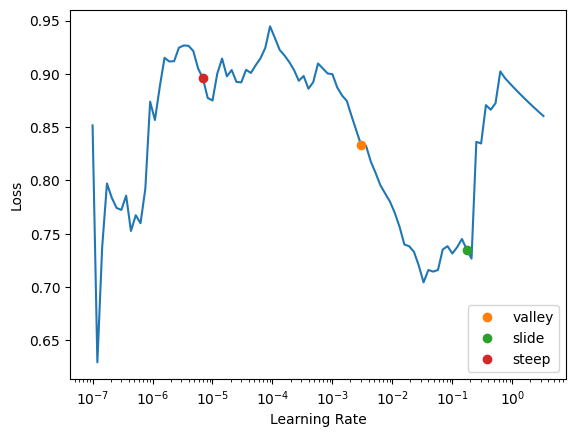

In [67]:
learner.lr_find(suggest_funcs=(valley,slide,steep))

In [68]:
learner.fit_one_cycle(15, 1e-3)

epoch,train_loss,valid_loss,accuracy,time
0,0.891734,0.617597,0.682243,00:01
1,0.680882,0.451572,0.766355,00:01
2,0.532479,0.426423,0.831776,00:01
3,0.408745,0.294104,0.925234,00:01
4,0.318947,0.221421,0.943925,00:01
5,0.262264,0.271749,0.887850,00:01
6,0.209936,0.182498,0.953271,00:01
7,0.154894,0.197008,0.915888,00:01
8,0.140672,0.128013,0.962617,00:01
9,0.175170,0.139006,0.962617,00:01


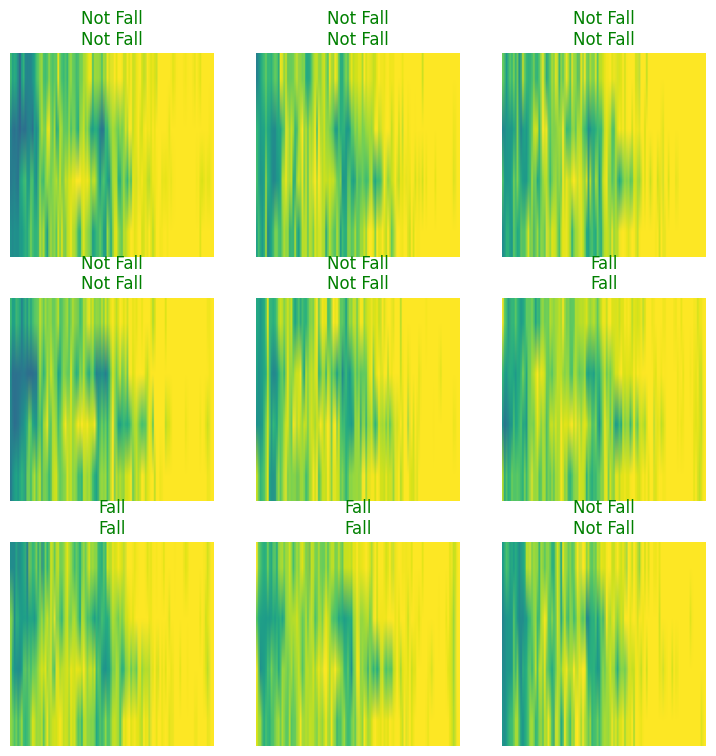

In [69]:
learner.show_results()

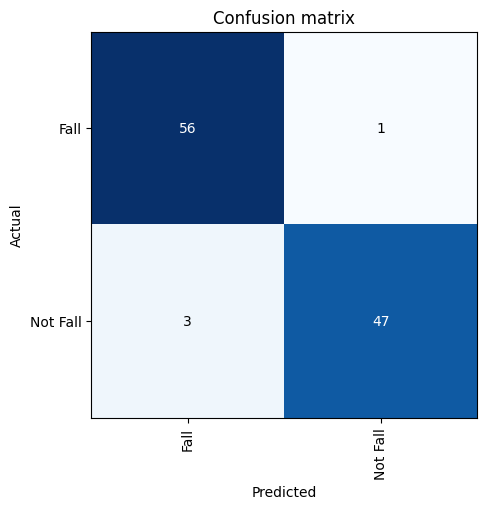

In [70]:
inter_plot = ClassificationInterpretation.from_learner(learner)
inter_plot.plot_confusion_matrix(figsize=(5,5))

In [71]:
def get_x_test(i):
    arr_db = 10 * np.log10(valid_spec[i])
    arr_db = np.clip(arr_db, FLOOR_DB, 0)

    # Scale to [0, 1]
    arr_01 = (arr_db - FLOOR_DB) / (-FLOOR_DB)

    # If spectrogram is multi-channel, convert to grayscale first
    if len(arr_01.shape) == 3:
            arr_01 = np.mean(arr_01, axis=-1)  # average across channels
    
    arr_01 = arr_01[:, ::-1].copy() # flip spectrogram
    
    # Apply colormap to convert grayscale to color
    # Popular colormaps for spectrograms: 'viridis', 'plasma', 'magma', 'inferno', 'jet', 'hot'
    colormap = plt.get_cmap('viridis')  # or try 'plasma', 'magma', 'jet'
    arr_colored = colormap(arr_01)  # This returns RGBA (H, W, 4)
    
    # Convert RGBA to RGB (drop alpha channel)
    arr_rgb = arr_colored[:, :, :3]  # (H, W, 3)
    
    # Convert to PyTorch tensor with correct channel ordering
    t = torch.tensor(arr_rgb).float().permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # Resize image
    t_resized = torch.nn.functional.interpolate(t, size=TARGET_HW, mode='bilinear', align_corners=False)
    
    return TensorImage(t_resized.squeeze(0))  # (3, H, W)


def get_y_test(i):
    return valid_labels[i]

In [72]:
def get_val_accuracy(learner : Learner):

    base = min(len(valid_spec), len(valid_labels))

    true_count = 0

    for i in range(base):
        if learner.predict(get_x_test(i))[0] == get_y_test(i):
            true_count += 1
    
    print(base)

    
    return true_count / base

In [73]:
accuracy = get_val_accuracy(learner)

50


In [74]:
accuracy

1.0

In [75]:
dir = Path('./models')

learner.path = dir

learner.export('autoencoder.pkl')

## Approch 2

- Threat the spectrogram arrays as a vector embedding, and compare the sematics to the training data.
- Stupid and fast. 
